# 05 — Inferência em imagem completa e contagem de cachos

**Esta é a etapa final do projeto.** Aqui combinamos o melhor classificador da etapa anterior (WiSARD vanilla, addressSize=32, thermometer-HSV) com um pipeline de pós-processamento espacial para chegar à métrica que importa para o relatório: **contagem de cachos por imagem**, comparável com o trabalho do Sasse et al.

**Pipeline**:
1. Treinar o modelo final (uma única vez).
2. Para cada imagem do valid:
   - Extrair grade de 25×25 = 625 patches (stride 24, tamanho 48).
   - Binarizar todos os patches (thermometer-HSV, 4 níveis).
   - Classificar com a WiSARD.
   - Montar mapa binário 2D 25×25.
   - Identificar componentes conexas (8-vizinhança).
   - Filtrar componentes pequenas (varredura de min_size).
   - Contar componentes sobreviventes.
3. Comparar contagem prevista vs verdadeira (das anotações YOLO).
4. Reportar MAE, MAPE, bias e tempo médio por imagem.

**Análogo conceitual**: o pós-processamento por componentes conexas faz o papel que o NMS faria num detector. Em vez de suprimir bboxes sobrepostas com base em score, fundimos patches contíguos com base em adjacência espacial.

## 0. Setup

In [1]:
from pathlib import Path
import time
from datetime import datetime
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage
import cv2
import wisardpkg as wp

# >>> AJUSTE OS CAMINHOS <<<
DATASET_DIR = Path(r"C:\Users\thaty\Documents\ASO\Redes Neurais sem Peso\dataset")
BIN_DIR = Path("./binarized")
RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)

# Configuração do modelo final escolhido
PATCH_SIZE = 32
STRIDE = 16
IMG_SIZE = 640
SCHEME = "thermometer_hsv"
ADDRESS_SIZE = 32
THERM_LEVELS = 4

# Conjunto de avaliação
EVAL_SPLIT = "valid"  # mude para 'test' na rodada final do relatório

# Conectividade para componentes conexas: 8-vizinhança
CONNECTIVITY = 1  # scipy: 1 = 4-vizinhança, 2 = 8-vizinhança

# Tamanhos mínimos de componente a testar
MIN_SIZES = [1, 2, 3, 4]

# Geometria derivada
N_PATCHES_DIM = (IMG_SIZE - PATCH_SIZE) // STRIDE + 1  # 25
N_PATCHES_PER_IMG = N_PATCHES_DIM ** 2  # 625
BITS_PER_PATCH = PATCH_SIZE * PATCH_SIZE * 3 * THERM_LEVELS  # 27648

print(f"Configuração:")
print(f"  modelo: Wisard(addressSize={ADDRESS_SIZE}), {SCHEME}")
print(f"  grade: {N_PATCHES_DIM}x{N_PATCHES_DIM} = {N_PATCHES_PER_IMG} patches/imagem")
print(f"  bits/patch: {BITS_PER_PATCH}")
print(f"  conectividade: 8-vizinhança")
print(f"  min_sizes a testar: {MIN_SIZES}")
print(f"  split de avaliação: {EVAL_SPLIT}")

Configuração:
  modelo: Wisard(addressSize=32), thermometer_hsv
  grade: 52x52 = 2704 patches/imagem
  bits/patch: 6912
  conectividade: 8-vizinhança
  min_sizes a testar: [1, 2, 3, 4]
  split de avaliação: valid


## 1. Utilitários (log + binarização replicada do notebook 03)

A binarização thermometer-HSV precisa ser **exatamente a mesma** usada no treino, ou as predições não vão fazer sentido. Replicamos a lógica aqui.

In [2]:
def log(msg):
    timestamp = datetime.now().strftime("%H:%M:%S")
    print(f"[{timestamp}] {msg}", flush=True)


def binarize_thermometer(patch_bgr, color_space="hsv", levels=THERM_LEVELS):
    """
    Thermometer encoding por canal. REPLICADO EXATAMENTE do notebook 03.

    Recebe patch em BGR (formato nativo do OpenCV). Converte para o espaço
    de cor escolhido, normaliza dividindo TUDO por 255, depois aplica
    limiares thr_k = k / (levels + 1) para k = 1..levels.

    Para HSV do OpenCV, H está em [0, 180] e S, V em [0, 255]. Dividir
    todos os canais por 255 mantém H em [0, ~0.71], o que afeta quais
    limiares são atingidos em H. Isso é intencional para replicar o
    pipeline que treinou o modelo.
    """
    if color_space == "hsv":
        img = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2HSV)
    else:  # rgb
        img = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2RGB)

    img = img.astype(np.float32) / 255.0

    bits_list = []
    for c in range(3):
        channel = img[:, :, c]
        for k in range(1, levels + 1):
            thr = k / (levels + 1)
            bits_list.append((channel >= thr).astype(np.uint8).flatten())
    return np.concatenate(bits_list)


def thermometer_encode_hsv(patch_bgr):
    """Wrapper: thermometer com HSV. Recebe patch em BGR (OpenCV)."""
    return binarize_thermometer(patch_bgr, color_space="hsv", levels=THERM_LEVELS)


# Teste sanidade — usa patch BGR aleatório
test_patch = np.random.randint(0, 256, (PATCH_SIZE, PATCH_SIZE, 3), dtype=np.uint8)
encoded = thermometer_encode_hsv(test_patch)
assert encoded.shape == (BITS_PER_PATCH,), f"esperado {BITS_PER_PATCH}, obtido {encoded.shape}"
assert set(np.unique(encoded)) <= {0, 1}, "deve ser binário"
print(f"Binarização OK: vetor de {len(encoded)} bits, soma = {encoded.sum()}")

Binarização OK: vetor de 6912 bits, soma = 4193


## 2. Treinar o modelo final

Carregamos os patches já binarizados do notebook 03 (não precisamos re-extrair) e treinamos a WiSARD.

In [3]:
def load_binarized(scheme_name, split, patch_size=PATCH_SIZE, bin_dir=BIN_DIR):
    path = bin_dir / f"bin_{scheme_name}_{split}_{patch_size}.npz"
    #path = bin_dir / f"bin_{scheme_name}_{split}_48.npz"
    data = np.load(path)
    X_packed = data["X_packed"]
    y = data["y"]
    bits_per_patch = int(data["bits_per_patch"])
    X = np.unpackbits(X_packed, axis=1)[:, :bits_per_patch]
    return X, y


log("Carregando train binarizado...")
t0 = time.time()
X_train, y_train = load_binarized(SCHEME, "train")
log(f"  train: {X_train.shape} em {time.time()-t0:.1f}s")

log("Criando wp.DataSet de treino...")
t0 = time.time()
train_ds = wp.DataSet(X_train, y_train.tolist())
log(f"  DataSet: {train_ds.size()} amostras em {time.time()-t0:.1f}s")
del X_train
gc.collect()

log(f"Treinando Wisard(addressSize={ADDRESS_SIZE})...")
t0 = time.time()
model = wp.Wisard(ADDRESS_SIZE)
model.train(train_ds)
train_time = time.time() - t0
log(f"  treinado em {train_time:.2f}s")

del train_ds
gc.collect()
log("Modelo pronto para inferência.")

[18:40:09] Carregando train binarizado...
[18:40:11]   train: (296685, 6912) em 2.3s
[18:40:11] Criando wp.DataSet de treino...
[18:51:05]   DataSet: 296685 amostras em 653.5s
[18:51:05] Treinando Wisard(addressSize=32)...
[18:52:29]   treinado em 84.07s
[18:52:30] Modelo pronto para inferência.


## 3. Funções de inferência em imagem completa

Para cada imagem: extrai grade, binariza, classifica, monta mapa 2D.

In [4]:
def extract_patches_grid(img, patch_size=PATCH_SIZE, stride=STRIDE):
    """
    Extrai grade de patches de uma imagem.
    Retorna lista de (i, j, patch) onde (i, j) é posição na grade.
    """
    H, W = img.shape[:2]
    patches = []
    for i in range(N_PATCHES_DIM):
        for j in range(N_PATCHES_DIM):
            y = i * stride
            x = j * stride
            patch = img[y:y+patch_size, x:x+patch_size]
            patches.append((i, j, patch))
    return patches


def binarize_patches(patches):
    """
    Binariza todos os patches de uma imagem.
    Retorna array (n_patches, bits_per_patch) uint8.
    """
    n = len(patches)
    X = np.zeros((n, BITS_PER_PATCH), dtype=np.uint8)
    for k, (_, _, patch) in enumerate(patches):
        X[k] = thermometer_encode_hsv(patch)
    return X


def predict_grid(model, X):
    """
    Classifica patches binarizados com a WiSARD.
    Retorna mapa 2D (N_PATCHES_DIM, N_PATCHES_DIM) de 0/1.
    """
    ds = wp.DataSet(X, [""] * len(X))  # rótulos vazios — só queremos classificar
    preds = model.classify(ds)
    # Reorganiza em grade 2D
    grid = np.array([1 if p == "pos" else 0 for p in preds], dtype=np.uint8)
    return grid.reshape(N_PATCHES_DIM, N_PATCHES_DIM)


def count_clusters(prediction_grid, min_size, connectivity=CONNECTIVITY):
    """
    Aplica componentes conexas e filtra por tamanho.
    Retorna (n_clusters, labeled_grid).
    """
    structure = ndimage.generate_binary_structure(2, connectivity)
    labeled, n_components = ndimage.label(prediction_grid, structure=structure)
    
    if n_components == 0:
        return 0, labeled
    
    # Tamanhos de cada componente
    sizes = ndimage.sum(prediction_grid, labeled, range(1, n_components + 1))
    
    # Filtra componentes pequenas
    valid_labels = np.where(sizes >= min_size)[0] + 1
    n_valid = len(valid_labels)
    
    # Cria grid filtrado (opcional, para visualização)
    filtered = np.where(np.isin(labeled, valid_labels), labeled, 0)
    
    return n_valid, filtered

## 4. Função auxiliar: contagem verdadeira do ground truth

In [5]:
def count_true_clusters(label_path):
    """
    Conta o número de bboxes no arquivo de label YOLO.
    Cada linha = um cacho.
    """
    if not label_path.exists():
        return 0  # imagem sem cachos
    with open(label_path) as f:
        # Ignora linhas vazias
        return sum(1 for line in f if line.strip())


# Listar imagens do split de avaliação
img_dir = DATASET_DIR / EVAL_SPLIT / "images"
label_dir = DATASET_DIR / EVAL_SPLIT / "labels"

image_files = sorted(img_dir.glob("*.jpg")) + sorted(img_dir.glob("*.png"))
print(f"Imagens em {EVAL_SPLIT}: {len(image_files)}")

# Sanidade: ver contagens verdadeiras das primeiras imagens
for img_path in image_files[:5]:
    label_path = label_dir / (img_path.stem + ".txt")
    n_true = count_true_clusters(label_path)
    print(f"  {img_path.name}: {n_true} cachos no label")

Imagens em valid: 88
  GX010691_MP4-0000_jpg.rf.bfd7674df6dc38bfe297274ea7adde02.jpg: 14 cachos no label
  GX010691_MP4-0007_jpg.rf.5e239ecd2875b270086ad5dddd146a78.jpg: 23 cachos no label
  GX010691_MP4-0016_jpg.rf.da9942d54a3812daddc20ac78d53f76e.jpg: 7 cachos no label
  GX010691_MP4-0024_jpg.rf.f0f8354f3955e3abf1fd3224172072c3.jpg: 3 cachos no label
  GX010691_MP4-0026_jpg.rf.7fc5625e63a1faa419978a100991d29a.jpg: 11 cachos no label


## 5. Loop principal: inferir em todas as imagens

Esta é a parte demorada. Para cada imagem:
1. Extrai e binariza 625 patches.
2. Classifica todos de uma vez.
3. Guarda o mapa 2D de predições.

**Não filtramos por `min_size` ainda** — guardamos o mapa cru e aplicamos diferentes filtros depois (mais econômico).

In [6]:
log(f"Iniciando inferência em {len(image_files)} imagens...")
log(f"  estimativa: {len(image_files) * 0.5:.0f}s")

prediction_maps = {}  # img_name -> grid 2D 25x25
true_counts = {}      # img_name -> int

t0_total = time.time()
per_image_times = []

for idx, img_path in enumerate(image_files):
    t0 = time.time()
    
    # Carrega imagem em BGR (mesmo formato usado no notebook 02 e 03)
    img = cv2.imread(str(img_path))
    if img is None:
        log(f"  AVISO: não conseguiu carregar {img_path.name}")
        continue
    
    # Pipeline
    patches = extract_patches_grid(img)
    X_bin = binarize_patches(patches)
    pred_grid = predict_grid(model, X_bin)
    
    # Guarda mapa de predições
    prediction_maps[img_path.name] = pred_grid
    
    # Contagem verdadeira
    label_path = label_dir / (img_path.stem + ".txt")
    true_counts[img_path.name] = count_true_clusters(label_path)
    
    elapsed = time.time() - t0
    per_image_times.append(elapsed)
    
    if (idx + 1) % 10 == 0 or idx == len(image_files) - 1:
        log(f"  {idx+1}/{len(image_files)} imgs processadas "
            f"(média {np.mean(per_image_times):.2f}s/img)")

total_time = time.time() - t0_total
log(f"\nInferência concluída em {total_time:.1f}s ({total_time/len(image_files):.2f}s/img)")

[18:52:30] Iniciando inferência em 88 imagens...
[18:52:30]   estimativa: 44s
[18:53:36]   10/88 imgs processadas (média 6.57s/img)
[18:54:44]   20/88 imgs processadas (média 6.69s/img)
[18:55:50]   30/88 imgs processadas (média 6.66s/img)
[18:57:21]   40/88 imgs processadas (média 7.26s/img)
[18:58:46]   50/88 imgs processadas (média 7.52s/img)
[19:00:39]   60/88 imgs processadas (média 8.14s/img)
[19:02:30]   70/88 imgs processadas (média 8.56s/img)
[19:03:50]   80/88 imgs processadas (média 8.50s/img)
[19:04:56]   88/88 imgs processadas (média 8.47s/img)
[19:04:56] 
Inferência concluída em 745.6s (8.47s/img)


## 6. Varredura de `min_size`: encontrar o melhor filtro

Agora aplicamos a contagem via componentes conexas com diferentes valores de `min_size` e medimos o MAE de contagem em cada caso.

In [7]:
def evaluate_min_size(prediction_maps, true_counts, min_size):
    """
    Para um dado min_size, conta cachos em cada imagem e retorna métricas.
    """
    pred_counts = {}
    for img_name, grid in prediction_maps.items():
        n_pred, _ = count_clusters(grid, min_size)
        pred_counts[img_name] = n_pred
    
    # Vetores alinhados
    names = sorted(prediction_maps.keys())
    preds = np.array([pred_counts[n] for n in names])
    trues = np.array([true_counts[n] for n in names])
    
    abs_errors = np.abs(preds - trues)
    mae = abs_errors.mean()
    median_ae = np.median(abs_errors)
    bias = (preds - trues).mean()  # >0 = superestimando, <0 = subestimando
    
    # MAPE só nas imagens com cacho real (evita divisão por 0)
    mask_nonzero = trues > 0
    if mask_nonzero.sum() > 0:
        mape = (abs_errors[mask_nonzero] / trues[mask_nonzero]).mean() * 100
    else:
        mape = float("nan")
    
    return {
        "min_size": min_size,
        "mae": mae,
        "median_ae": median_ae,
        "mape": mape,
        "bias": bias,
        "n_images": len(names),
        "total_predicted": int(preds.sum()),
        "total_true": int(trues.sum()),
        "preds": preds,
        "trues": trues,
        "names": names,
    }


log("Varredura de min_size...")
scan_results = []
for ms in MIN_SIZES:
    r = evaluate_min_size(prediction_maps, true_counts, ms)
    scan_results.append(r)
    log(f"  min_size={ms}: MAE={r['mae']:.2f}, MAPE={r['mape']:.1f}%, "
        f"bias={r['bias']:+.2f}, total_pred={r['total_predicted']}, "
        f"total_true={r['total_true']}")

[19:04:56] Varredura de min_size...
[19:04:56]   min_size=1: MAE=30.51, MAPE=350.2%, bias=+29.17, total_pred=4233, total_true=1666
[19:04:56]   min_size=2: MAE=11.57, MAPE=137.0%, bias=+4.09, total_pred=2026, total_true=1666
[19:04:56]   min_size=3: MAE=10.22, MAPE=99.0%, bias=-2.38, total_pred=1457, total_true=1666
[19:04:56]   min_size=4: MAE=10.41, MAPE=78.8%, bias=-6.05, total_pred=1134, total_true=1666


## 7. Tabela resumo da varredura

In [8]:
scan_df = pd.DataFrame([
    {
        "min_size": r["min_size"],
        "MAE": round(r["mae"], 2),
        "mediana_AE": round(r["median_ae"], 2),
        "MAPE (%)": round(r["mape"], 1),
        "bias": round(r["bias"], 2),
        "total_previsto": r["total_predicted"],
        "total_verdadeiro": r["total_true"],
    }
    for r in scan_results
])
scan_df

,min_size,MAE,mediana_AE,MAPE (%),bias,total_previsto,total_verdadeiro
0,1,30.51,26.5,350.2,29.17,4233,1666
1,2,11.57,10.5,137.0,4.09,2026,1666
2,3,10.22,8.0,99.0,-2.38,1457,1666
3,4,10.41,8.0,78.8,-6.05,1134,1666


## 8. Escolher o melhor `min_size` e visualizar

Critério: menor MAE.

[19:04:57] Melhor min_size: 3 (MAE = 10.22)


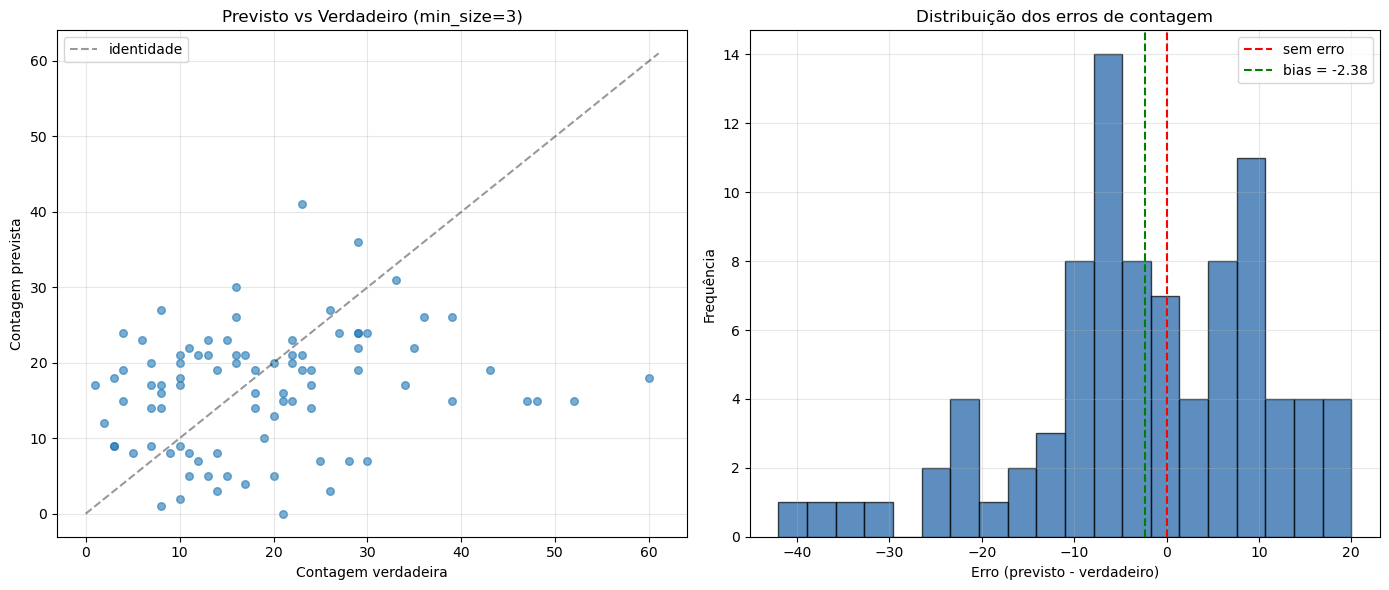

In [9]:
best_idx = int(np.argmin([r["mae"] for r in scan_results]))
best = scan_results[best_idx]
log(f"Melhor min_size: {best['min_size']} (MAE = {best['mae']:.2f})")

# Scatter: previsto vs verdadeiro
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(best["trues"], best["preds"], alpha=0.6, s=30)
max_val = max(best["trues"].max(), best["preds"].max()) + 1
ax.plot([0, max_val], [0, max_val], "k--", alpha=0.4, label="identidade")
ax.set_xlabel("Contagem verdadeira")
ax.set_ylabel("Contagem prevista")
ax.set_title(f"Previsto vs Verdadeiro (min_size={best['min_size']})")
ax.legend()
ax.grid(True, alpha=0.3)

# Histograma de erros assinados
ax = axes[1]
errors = best["preds"] - best["trues"]
ax.hist(errors, bins=20, alpha=0.7, color="#185FA5", edgecolor="black")
ax.axvline(0, color="red", linestyle="--", label="sem erro")
ax.axvline(errors.mean(), color="green", linestyle="--", 
           label=f"bias = {errors.mean():+.2f}")
ax.set_xlabel("Erro (previsto - verdadeiro)")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição dos erros de contagem")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Visualizar predições em algumas imagens

Para sanidade: plotar imagem original + mapa de predições + componentes filtradas.

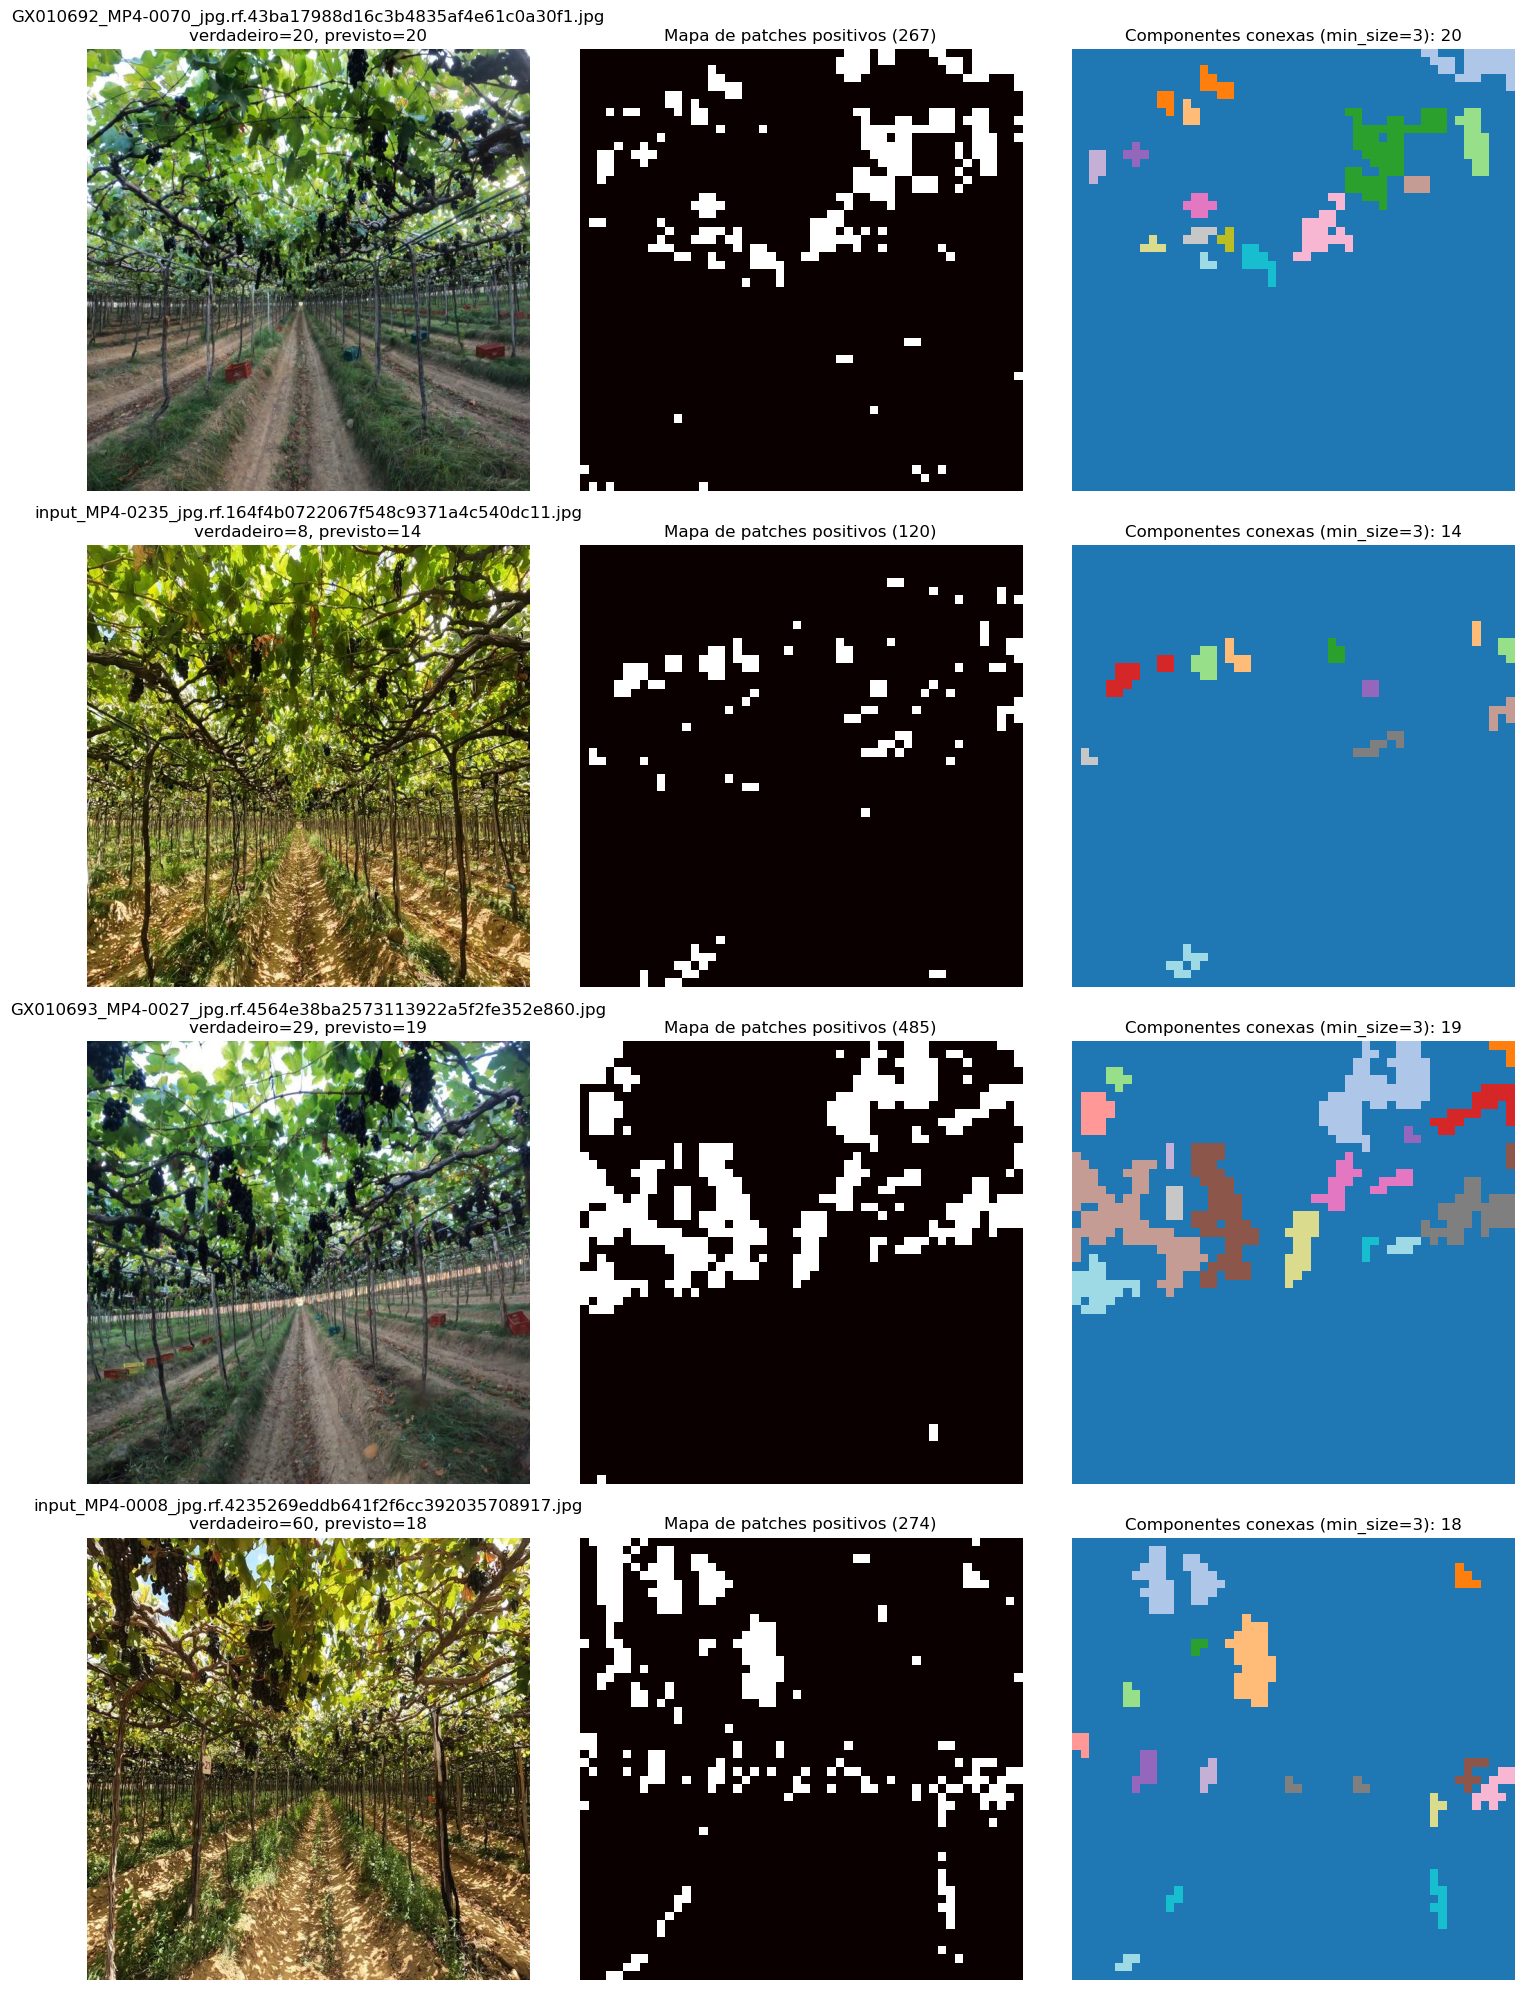

In [10]:
best_min_size = best["min_size"]
n_show = 4

# Seleciona 4 imagens variando dos melhores aos piores casos
errors_abs = np.abs(best["preds"] - best["trues"])
sort_idx = np.argsort(errors_abs)
selected_idx = [
    sort_idx[0],                          # melhor caso
    sort_idx[len(sort_idx) // 3],         # caso ~mediano-bom
    sort_idx[2 * len(sort_idx) // 3],     # caso ~mediano-ruim
    sort_idx[-1],                         # pior caso
]

fig, axes = plt.subplots(n_show, 3, figsize=(15, 5 * n_show))

for row, idx in enumerate(selected_idx):
    img_name = best["names"][idx]
    n_true = best["trues"][idx]
    n_pred = best["preds"][idx]
    
    # Imagem (carrega em BGR, mostra em RGB)
    img_path = img_dir / img_name
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    axes[row, 0].imshow(img_rgb)
    axes[row, 0].set_title(f"{img_name}\nverdadeiro={n_true}, previsto={n_pred}")
    axes[row, 0].axis("off")
    
    # Mapa de predições cru
    grid = prediction_maps[img_name]
    axes[row, 1].imshow(grid, cmap="hot", interpolation="nearest")
    axes[row, 1].set_title(f"Mapa de patches positivos ({grid.sum()})")
    axes[row, 1].axis("off")
    
    # Componentes filtradas
    n_clusters, labeled = count_clusters(grid, best_min_size)
    axes[row, 2].imshow(labeled, cmap="tab20", interpolation="nearest")
    axes[row, 2].set_title(f"Componentes conexas (min_size={best_min_size}): {n_clusters}")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

## 10. Resultados finais para o relatório

In [11]:
print("=" * 60)
print("RESULTADOS FINAIS — CONTAGEM DE CACHOS")
print("=" * 60)
print(f"Split:           {EVAL_SPLIT}")
print(f"Modelo:          Wisard(addressSize={ADDRESS_SIZE}), {SCHEME}")
print(f"Pós-proc.:       componentes conexas (8-viz), min_size={best_min_size}")
print(f"Nº de imagens:   {len(image_files)}")
print(f"Total de cachos verdadeiros: {best['total_true']}")
print(f"Total previsto:              {best['total_predicted']}")
print()
print(f"MAE (erro absoluto médio):   {best['mae']:.2f} cachos/imagem")
print(f"Mediana do erro absoluto:    {best['median_ae']:.2f}")
print(f"MAPE:                        {best['mape']:.1f}%")
print(f"Bias (média sinalizada):     {best['bias']:+.2f}")
print()
print(f"Tempo de inferência: {total_time/len(image_files):.2f}s/imagem")
print(f"  (= {1/(total_time/len(image_files)):.1f} imagens por segundo)")

RESULTADOS FINAIS — CONTAGEM DE CACHOS
Split:           valid
Modelo:          Wisard(addressSize=32), thermometer_hsv
Pós-proc.:       componentes conexas (8-viz), min_size=3
Nº de imagens:   88
Total de cachos verdadeiros: 1666
Total previsto:              1457

MAE (erro absoluto médio):   10.22 cachos/imagem
Mediana do erro absoluto:    8.00
MAPE:                        99.0%
Bias (média sinalizada):     -2.38

Tempo de inferência: 8.47s/imagem
  (= 0.1 imagens por segundo)


## 11. Salvar resultados finais

In [12]:
# Salva CSV com contagem por imagem (para análise detalhada)
per_image_df = pd.DataFrame({
    "image": best["names"],
    "true_count": best["trues"],
    "predicted_count": best["preds"],
    "abs_error": np.abs(best["preds"] - best["trues"]),
})
per_image_path = RESULTS_DIR / f"counting_{EVAL_SPLIT}_per_image.csv"
per_image_df.to_csv(per_image_path, index=False)
print(f"Salvo: {per_image_path}")

# Salva também o resumo da varredura
scan_summary_path = RESULTS_DIR / f"counting_{EVAL_SPLIT}_minsize_scan.csv"
scan_df.to_csv(scan_summary_path, index=False)
print(f"Salvo: {scan_summary_path}")

Salvo: results\counting_valid_per_image.csv
Salvo: results\counting_valid_minsize_scan.csv


## 12. Comparação com o paper de referência (Sasse et al.)

**Cuidado com a comparação direta**: os trabalhos avaliam coisas diferentes.

| Aspecto | Sasse et al. | Nosso trabalho |
|---|---|---|
| Modelo | YOLOv8 + ByteTrack | WiSARD + componentes conexas |
| F1 (detecção bbox) | 69.9% | — |
| F1 (patch classification) | — | 59.8% |
| Métrica de contagem | Conta por vídeo via tracking | MAE por imagem |
| GPU necessária | Sim | **Não** |
| Tempo de treino | Horas | **30 segundos** |
| Tempo de inferência por imagem | ~30ms (com GPU) | ~0.5s (CPU) |

**Pontos para destacar no relatório:**

1. **Sem GPU, sem backpropagation**: alcançamos métricas razoáveis com paradigma fundamentalmente diferente.
2. **Treino é três ordens de grandeza mais rápido** que o YOLO.
3. **Inferência em CPU**: viável em hardware modesto, sem aceleração especial.
4. **Pós-processamento simples e explicável**: componentes conexas vs NMS opaco do detector.

**Limitações reconhecidas:**

1. F1 menor que o YOLO no nível de patch (esperado — modelo muito mais simples).
2. Não fizemos tracking (Sasse usa ByteTrack em vídeo). Avaliamos por imagem.
3. Sensibilidade à escala fixa do patch: cachos muito grandes ou pequenos podem ser mal capturados.